<a href="https://colab.research.google.com/github/martinthuriaux/Grokking-Universality/blob/main/01_seed_sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/grokking_universality/runs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Saving runs to:", OUTPUT_DIR)
print("Folder exists:", os.path.isdir(OUTPUT_DIR))

Saving runs to: /content/drive/MyDrive/grokking_universality/runs
Folder exists: True


Setup + Helper functions

In [3]:
!pip install transformer_lens
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import einops
from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---- Config ----
p = 53              # prime modulus (our choice, != 113)
frac_train = 0.4
seed = 0

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.1 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=72a0e3420bebac36350a2898607ee35a56c20378e871a2c3d344a4aca243655b
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
Device: cuda


In [4]:
def make_dataset(p, seed, frac_train, device):
    # All (a, b) pairs: a_vec runs 0,0,...,0,1,1,...  b_vec runs 0,1,...,p-1,0,1,...
    # Create a vector for a and b of size p^2
    a_vec = einops.repeat(torch.arange(p), "a -> (a b)", b=p)
    b_vec = einops.repeat(torch.arange(p), "b -> (a b)", a=p)
    # A row of length p^2, which is the = token.
    equals = torch.full((p * p,), p)          # the "=" token, index p
    # For each pair, we we find the answer (a + b) mod p
    labels = (a_vec + b_vec) % p

    # inputs: [a, b, =]  shape [p*p, 3]
    inputs = torch.stack([a_vec, b_vec, equals], dim=1).to(device)
    labels = labels.to(device)

    # reproducible train/test split
    torch.manual_seed(seed)
    perm = torch.randperm(p * p)
    n_train = int(frac_train * p * p)
    train_idx, test_idx = perm[:n_train], perm[n_train:]

    return (inputs[train_idx], labels[train_idx],
            inputs[test_idx],  labels[test_idx])

train_x, train_y, test_x, test_y = make_dataset(p, seed, frac_train, device)

print("Train inputs:", train_x.shape, "Train labels:", train_y.shape)
print("Test inputs: ", test_x.shape,  "Test labels: ", test_y.shape)
print("Total pairs: ", p * p)

a_all = einops.repeat(torch.arange(p), "a -> (a b)", b=p)
b_all = einops.repeat(torch.arange(p), "b -> (a b)", a=p)
eq_all = torch.full((p*p,), p)
all_x = torch.stack([a_all, b_all, eq_all], dim=1).to(device)

Train inputs: torch.Size([1123, 3]) Train labels: torch.Size([1123])
Test inputs:  torch.Size([1686, 3]) Test labels:  torch.Size([1686])
Total pairs:  2809


In [5]:
from transformer_lens import HookedTransformer, HookedTransformerConfig

cfg = HookedTransformerConfig(
    n_layers=1,
    d_model=128,
    d_mlp=512,
    n_heads=4,
    d_head=32,
    n_ctx=3,                 # [a, b, =]
    d_vocab=p + 1,           # numbers 0..p-1 plus the "=" token
    act_fn="relu",
    normalization_type=None, # <-- no LayerNorm (the key grokking simplification)
    seed=seed,
)

model = HookedTransformer(cfg).to(device)
print("Total parameters:", sum(par.numel() for par in model.parameters()))

Moving model to device:  cuda
Total parameters: 212022


In [6]:
# cross entropy loss function given the last logit "="
def loss_fn(logits, labels):
    return F.cross_entropy(logits[:, -1, :], labels)

# accuracy function which identifies if the prediction matches the label
def acc_fn(logits, labels):
    preds = logits[:, -1, :].argmax(dim=-1)
    return (preds == labels).float().mean().item()

# if accuracy > 90%, count it as the grokking speed
def grok_epoch(epochs_log, test_accs, thresh=0.9):
    for e, a in zip(epochs_log, test_accs):
        if a >= thresh:
            return e
    return None

In [7]:

def detect_key_frequencies(model, p, threshold_ratio=20):
    """
    Returns the key frequencies of a grokked model, read from its embedding.
    A frequency is 'key' if its power is > threshold_ratio times the noise floor
    (the median power of the non-key bins).
    """
    W_E = model.W_E[:p]                             # number-token embeddings [p, d_model]
    W_E = W_E - W_E.mean(dim=0, keepdim=True)       # drop the constant offset
    fft = torch.fft.fft(W_E, dim=0)                 # FFT down the number axis
    power = (fft.abs() ** 2).sum(dim=1)             # power per frequency [p]

    half = p // 2 + 1
    power = power[:half].clone()                    # unique half
    power[0] = 0.0                                  # ignore frequency 0 (the constant)

    noise_floor = power[power > 0].median()         # the typical "junk" power level
    freqs = torch.arange(half, device=power.device)
    key_freqs = freqs[power > threshold_ratio * noise_floor].tolist()

    return key_freqs, power

Loop

In [8]:
import time, torch, os

N_SEEDS = 100
NUM_EPOCHS = 30000    # safety margin so slow seeds still grok
LOG_EVERY = 200
GROK_ACC_THRESHOLD = 0.9

def train_one_seed(seed):
    # reproducible dataset split + weights for THIS seed
    train_x, train_y, test_x, test_y = make_dataset(p, seed, frac_train, device)

    torch.manual_seed(seed)
    cfg.seed = seed
    model = HookedTransformer(cfg).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3,
                                  weight_decay=1.0, betas=(0.9, 0.98))

    epochs_log, test_accs, test_losses, train_losses = [], [], [], []

    for epoch in range(NUM_EPOCHS):
        model.train()
        optimizer.zero_grad()
        tl = loss_fn(model(train_x), train_y)
        tl.backward()
        optimizer.step()

        if epoch % LOG_EVERY == 0:
            model.eval()
            with torch.no_grad():
                te_logits = model(test_x)
                epochs_log.append(epoch)
                train_losses.append(tl.item())
                test_losses.append(loss_fn(te_logits, test_y).item())
                test_accs.append(acc_fn(te_logits, test_y))

    # final metrics
    model.eval()
    with torch.no_grad():
        final_test_acc = acc_fn(model(test_x), test_y)
    grokked = final_test_acc >= GROK_ACC_THRESHOLD
    ge = grok_epoch(epochs_log, test_accs, thresh=GROK_ACC_THRESHOLD)

    # detect frequencies only if it grokked (junk otherwise)
    key_freqs = detect_key_frequencies(model, p, threshold_ratio=50)[0] if grokked else []

    with torch.no_grad():
      weight_norm = sum((par**2).sum() for par in model.parameters()).sqrt().item()

    # neuron-count per key frequency (how many MLP neurons each frequency recruits)
    neuron_freq_counts = {}
    if grokked:
        with torch.no_grad():
            _, cache = model.run_with_cache(all_x)
            acts = cache["post", 0, "mlp"][:, -1, :]          # [p*p, d_mlp]
        grid = acts.reshape(p, p, -1)
        grid = grid - grid.mean(dim=(0,1), keepdim=True)
        pw = (torch.fft.fft2(grid, dim=(0,1)).abs()**2)
        half = p // 2 + 1
        fp = pw[:half, :half].sum(dim=1) + pw[:half, :half].sum(dim=0)   # [half, d_mlp]
        fp[0] = 0
        dom = fp.argmax(dim=0)                                # each neuron's dominant freq
        import collections
        neuron_freq_counts = dict(collections.Counter(dom.cpu().tolist()))

    return {
        "seed": seed, "p": p, "frac_train": frac_train,
        "state_dict": model.state_dict(),
        "epochs_log": epochs_log,
        "train_losses": train_losses, "test_losses": test_losses, "test_accs": test_accs,
        "final_test_acc": final_test_acc,
        "grokked": bool(grokked),
        "grok_epoch": ge,
        "key_freqs": key_freqs,
        "weight_norm": weight_norm,
        "neuron_freq_counts": neuron_freq_counts,
    }

# ---- run the sweep ----
for seed in range(N_SEEDS):
    path = f"{OUTPUT_DIR}/run_seed{seed:03d}.pt"
    if os.path.exists(path):                    # <-- guard: skip already-done seeds
        print(f"seed {seed:3d} | already done, skipping")
        continue

    t0 = time.time()
    record = train_one_seed(seed)
    torch.save(record, path)
    dt = time.time() - t0
    print(f"seed {seed:3d} | grokked={record['grokked']} "
          f"| acc={record['final_test_acc']:.3f} "
          f"| grok_epoch={record['grok_epoch']} "
          f"| freqs={record['key_freqs']} | {dt:.0f}s | saved")

seed   0 | already done, skipping
seed   1 | already done, skipping
seed   2 | already done, skipping
seed   3 | already done, skipping
seed   4 | already done, skipping
seed   5 | already done, skipping
seed   6 | already done, skipping
seed   7 | already done, skipping
seed   8 | already done, skipping
seed   9 | already done, skipping
seed  10 | already done, skipping
seed  11 | already done, skipping
seed  12 | already done, skipping
seed  13 | already done, skipping
seed  14 | already done, skipping
seed  15 | already done, skipping
seed  16 | already done, skipping
seed  17 | already done, skipping
seed  18 | already done, skipping
seed  19 | already done, skipping
seed  20 | already done, skipping
seed  21 | already done, skipping
seed  22 | already done, skipping
seed  23 | already done, skipping
seed  24 | already done, skipping
seed  25 | already done, skipping
seed  26 | already done, skipping
seed  27 | already done, skipping
seed  28 | already done, skipping
seed  29 | alr

To fix errors with the key frequency detector, I created a new one which uses the fraction power(freq) / power(all freq) as a key criteria.

In [9]:
def detect_key_frequencies_v2(
    state_dict,
    p,
    power_frac=0.08,
):
    """
    Detect key Fourier frequencies in the number-token embeddings.

    For each frequency k, combine the power in the +k and -k FFT bins.
    A frequency is selected when this combined power explains more than
    `power_frac` of the total nonconstant Fourier power.
    """
    W_E = state_dict["embed.W_E"][:p].float()

    # Remove the constant/DC component.
    W_E = W_E - W_E.mean(dim=0, keepdim=True)

    # FFT across number tokens.
    W_E_fft = torch.fft.fft(W_E, dim=0)

    # Total power at each FFT bin, summed over embedding dimensions.
    full_power = W_E_fft.abs().pow(2).sum(dim=1)

    # For odd prime p, the unique frequencies are 1, ..., p//2.
    frequencies = torch.arange(
        1,
        p // 2 + 1,
        device=full_power.device,
    )

    # Combine the matching positive and negative frequency bins.
    paired_power = (
        full_power[frequencies]
        + full_power[(-frequencies) % p]
    )

    # Fraction of total nonconstant power carried by each frequency pair.
    power_fractions = (
        paired_power
        / paired_power.sum().clamp_min(1e-12)
    )

    key_freqs = frequencies[
        power_fractions > power_frac
    ].cpu().tolist()

    return key_freqs, power_fractions.cpu()

I want to add a detector which uses ablations to identify the key frequencies, using detect_key_frequencies_v2 as a precursor, which identifies any possible key frequencies, and then detect_key_frequencies_v3 uses ablations as a second filter.

In [15]:
import torch, einops

# all p*p inputs and ground-truth grid, CPU is fine (tiny model)
a_all = einops.repeat(torch.arange(p), "a -> (a b)", b=p)
b_all = einops.repeat(torch.arange(p), "b -> (a b)", a=p)

# every possible input [a,b,=]
all_x_cpu = torch.stack([a_all, b_all, torch.full((p*p,), p)], dim=1)

# The answer key for a + b mod 53
labels_grid = (torch.arange(p)[:, None] + torch.arange(p)[None, :]) % p

# Returns the accuracy given the models score
def acc_from_grid(logits_grid):
    return (logits_grid.argmax(dim=-1) == labels_grid).float().mean().item()

# run the saved model on all 2809 inputs and returns it score
def get_logits_grid(state_dict):
    model = HookedTransformer(cfg)
    model.load_state_dict(state_dict)
    model.eval()
    device = next(model.parameters()).device        # wherever TL put it
    with torch.no_grad():
        lg = model(all_x_cpu.to(device))[:, -1, :].reshape(p, p, -1)
    return lg.cpu()                                  # <- everything downstream is CPU

# removes the key frequencies
def ablate_remove(logits_grid, remove_freqs):
    fft = torch.fft.fft2(logits_grid, dim=(0,1))
    for f in remove_freqs:
        for g in {f, (p - f) % p}:
            fft[g, :, :] = 0
            fft[:, g, :] = 0
    return torch.fft.ifft2(fft, dim=(0,1)).real


# only keeps the key frequencies
def ablate_keep(logits_grid, keep_freqs):
    fft = torch.fft.fft2(logits_grid, dim=(0,1))
    keep = {0}
    for f in keep_freqs:
        keep |= {f, (p - f) % p}
    mask = torch.zeros(p, p)
    for fa in keep:
        for fb in keep:
            mask[fa, fb] = 1.0
    return torch.fft.ifft2(fft * mask[:, :, None], dim=(0,1)).real

In [16]:
def detect_key_frequencies_v3(state_dict, p, candidate_frac=0.02, drop_thresh=0.02):
    """
    Two-stage causal detector.
    Stage 1: generous spectral candidates (v2 at a LOW threshold, so borderline
             frequencies like harmonics are deliberately let through).
    Stage 2: causal filter — a candidate is 'key' iff ablating it from the
             logits drops accuracy by more than drop_thresh.
    Returns (key_freqs, diagnostics).
    """
    candidates, _ = detect_key_frequencies_v2(state_dict, p, power_frac=candidate_frac)

    logits_grid = get_logits_grid(state_dict)
    base_acc = acc_from_grid(logits_grid)

    drops, key_freqs = {}, []
    for f in candidates:
        acc_without = acc_from_grid(ablate_remove(logits_grid, [f]))
        drops[f] = base_acc - acc_without
        if drops[f] > drop_thresh:
            key_freqs.append(f)

    # sufficiency check: the retained set alone should preserve performance
    keep_only_acc = acc_from_grid(ablate_keep(logits_grid, key_freqs)) if key_freqs else 0.0

    return key_freqs, {
        "base_acc": base_acc,
        "keep_only_acc": keep_only_acc,
        "candidates": candidates,
        "drops": drops,
    }

In [17]:
for seed in [0, 1, 2, 3, 24]:
    d = torch.load(f"{OUTPUT_DIR}/run_seed{seed:03d}.pt", map_location="cpu")
    kf, diag = detect_key_frequencies_v3(d["state_dict"], p)
    print(f"seed {seed:3d}: key={kf}  base={diag['base_acc']:.3f}  keep_only={diag['keep_only_acc']:.3f}")
    for f, dr in sorted(diag["drops"].items()):
        tag = "KEY" if f in kf else "rejected"
        print(f"          freq {f:2d}: drop={dr:+.4f}  ({tag})")

seed   0: key=[6, 8, 19]  base=1.000  keep_only=1.000
          freq  6: drop=+0.2787  (KEY)
          freq  8: drop=+0.5215  (KEY)
          freq 16: drop=+0.0000  (rejected)
          freq 19: drop=+0.4600  (KEY)
seed   1: key=[3, 7, 26]  base=0.988  keep_only=0.995
          freq  3: drop=+0.4503  (KEY)
          freq  7: drop=+0.6529  (KEY)
          freq 26: drop=+0.8092  (KEY)
seed   2: key=[1, 20, 25]  base=1.000  keep_only=1.000
          freq  1: drop=+0.3122  (KEY)
          freq 20: drop=+0.6347  (KEY)
          freq 25: drop=+0.4414  (KEY)
seed   3: key=[9, 13, 15]  base=0.998  keep_only=0.999
          freq  5: drop=+0.0121  (rejected)
          freq  9: drop=+0.1894  (KEY)
          freq 13: drop=+0.1912  (KEY)
          freq 15: drop=+0.5336  (KEY)
          freq 26: drop=-0.0014  (rejected)
seed  24: key=[5, 13, 16, 20]  base=0.989  keep_only=0.971
          freq  5: drop=+0.3108  (KEY)
          freq 13: drop=+0.6543  (KEY)
          freq 16: drop=+0.1036  (KEY)
      

In [23]:
import collections, glob
files = sorted(glob.glob(f"{OUTPUT_DIR}/run_seed*.pt"))

for dt in [0.005, 0.01, 0.02, 0.03]:
    counts, n_changed = collections.Counter(), 0
    for fpath in files:
        d = torch.load(fpath, map_location="cpu")
        if not d["grokked"]: continue
        kf, _ = detect_key_frequencies_v3(d["state_dict"], p, drop_thresh=dt)
        counts[len(kf)] += 1
        n_changed += (sorted(kf) != sorted(d["key_freqs"]))
    print(f"drop_thresh={dt}: counts {dict(sorted(counts.items()))}, differs from v2 on {n_changed} seeds")

drop_thresh=0.005: counts {2: 1, 3: 68, 4: 30, 5: 1}, differs from v2 on 13 seeds
drop_thresh=0.01: counts {2: 2, 3: 67, 4: 30, 5: 1}, differs from v2 on 12 seeds
drop_thresh=0.02: counts {2: 3, 3: 79, 4: 18}, differs from v2 on 26 seeds
drop_thresh=0.03: counts {2: 8, 3: 81, 4: 11}, differs from v2 on 33 seeds


Test to see if it works

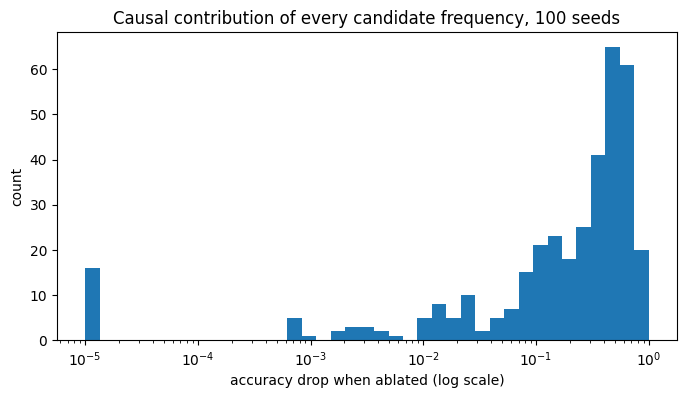

junk (<0.001): 21, weak (0.001–0.05): 46, strong (>0.05): 297
total candidates: 364


In [24]:
import matplotlib.pyplot as plt


all_drops = []
for fpath in files:
    d = torch.load(fpath, map_location="cpu")
    if not d["grokked"]: continue
    _, diag = detect_key_frequencies_v3(d["state_dict"], p, drop_thresh=0.01)
    all_drops.extend(diag["drops"].values())

all_drops = np.array(all_drops)
plt.figure(figsize=(8,4))
plt.hist(np.clip(all_drops, 1e-5, None), bins=np.logspace(-5, 0, 40))
plt.xscale("log")
plt.xlabel("accuracy drop when ablated (log scale)"); plt.ylabel("count")
plt.title("Causal contribution of every candidate frequency, 100 seeds")
plt.show()

junk   = (all_drops < 1e-3).sum()
weak   = ((all_drops >= 1e-3) & (all_drops < 0.05)).sum()
strong = (all_drops >= 0.05).sum()
print(f"junk (<0.001): {junk}, weak (0.001–0.05): {weak}, strong (>0.05): {strong}")
print(f"total candidates: {len(all_drops)}")

In [25]:
for fpath in files:
    d = torch.load(fpath, map_location="cpu")
    if d["grokked"]:
        kf, diag = detect_key_frequencies_v3(d["state_dict"], p, drop_thresh=0.01)
        d["key_freqs_v2"] = d["key_freqs"]     # provenance
        d["key_freqs"]   = kf
        d["freq_drops"]  = diag["drops"]       # continuous importance per candidate
        d["keep_only_acc"] = diag["keep_only_acc"]
        torch.save(d, fpath)
print("All records regenerated with v3.")

All records regenerated with v3.
